In [97]:
!pip install qiskit[visualization] qiskit-aer qiskit-ibm-runtime

In [98]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2
import numpy as np
from numpy import pi
import matplotlib.pyplot as plt
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit import transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.transpiler import generate_preset_pass_manager, PassManager, StagedPassManager

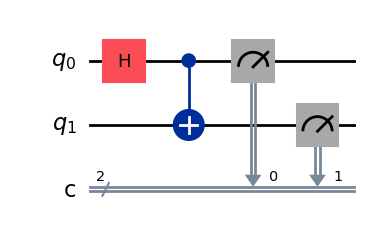

In [99]:
#creating the circuit
qr=QuantumRegister(2,'q')
cr=ClassicalRegister(2,'c')
qc=QuantumCircuit(qr,cr)

qc.h(qr[0])
qc.cx(qr[0],qr[1])   #qr[0]-control, qr[1]-target
# qc.measure_all()
qc.measure([qr[0],qr[1]], [cr[0],cr[1]])
qc.draw(output='mpl')
# qc.draw()


In [100]:
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="LFsogztwnQVatNMK70c2hV_PMd7h_2-5vYl8zvCBI24p", overwrite=True)

In [101]:
#Choose simulators, primitives and real hardware
simulator=AerSimulator()
sampler = StatevectorSampler()
service = QiskitRuntimeService()
backend = service.least_busy(operational=True, simulator=False)
print(simulator.name)
# print(sampler)
print(type(sampler).__name__)
# print(sampler.__class__.__name__)
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-01-14 13:39:34,066: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-14 13:39:34,442: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-01-14 13:39:37,070: Using instance: open-instance, plan: open


aer_simulator
StatevectorSampler
ibm_fez


In [102]:
tr_1 = transpile(qc, simulator)
tr_1.draw()
# print(tr_1)


┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

In [103]:
gpm1 = generate_preset_pass_manager(optimization_level=3, backend=backend,
    routing_method="sabre",
    approximation_degree=0.9,
    seed_transpiler=42,
    qubits_initially_zero=True)
gpm2 = generate_preset_pass_manager(backend=backend)

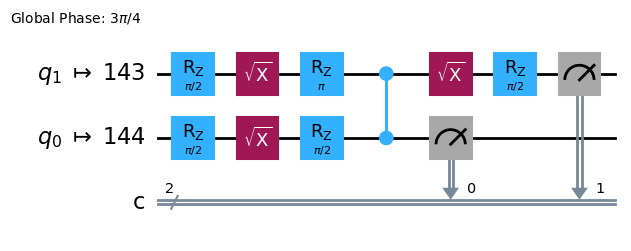

In [104]:
tr_gpm1 = gpm1.run(qc)
tr_gpm1.draw(output = 'mpl')

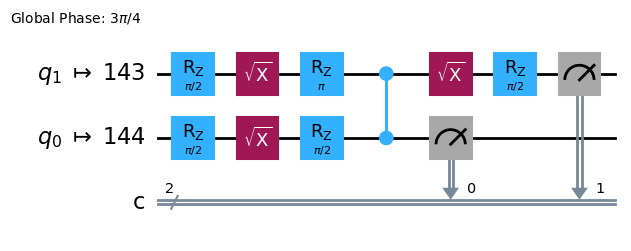

In [105]:
tr_gpm2 = gpm2.run(qc)
tr_gpm2.draw(output = 'mpl')

In [110]:
from qiskit.transpiler import CouplingMap
from qiskit.transpiler.passes import (
    SabreLayout,
    SabreSwap,
    BasicSwap,
    LookaheadSwap,
    Decompose,
    Unroll3qOrMore,
)

# 1. Setup a backend and a circuit
# below line of code retrieves the specific physical connectivity constraints of the target quantum processor defined by the backend object
coupling_map = backend.coupling_map

# 2. Define custom PassManagers for the first three stages
# We'll use specific passes for each stage for demonstration
init_pm = PassManager([Unroll3qOrMore()]) # Convert 3q gates (like Toffoli) to 1q and 2q gates
layout_pm = PassManager([SabreLayout(coupling_map=coupling_map, seed=42)]) # Find an optimized initial layout
routing_pm = PassManager([SabreSwap(coupling_map=coupling_map)]) # Insert SWAP gates to satisfy connectivity

# 3. Create a StagedPassManager to run only these three stages

# Note: The stages attribute defines the order of execution
staged_pm = StagedPassManager(
    stages=["init", "layout", "routing"],
    init=init_pm,
    layout=layout_pm,
    routing=routing_pm,
)

# 4. Run the StagedPassManager on the circuit
transpiled_qc = staged_pm.run(qc)

print("\nTranspiled Circuit (after init, layout, routing stages):")
print(transpiled_qc.draw(output='text', idle_wires=False))
print(f"\nOriginal Depth: {qc.depth()}, Transpiled Depth: {transpiled_qc.depth()}")



Transpiled Circuit (after init, layout, routing stages):
               ┌───┐   ┌─┐
q_1 -> 49 ─────┤ X ├───┤M├
          ┌───┐└─┬─┘┌─┐└╥┘
q_0 -> 50 ┤ H ├──■──┤M├─╫─
          └───┘     └╥┘ ║ 
     c: 2/═══════════╩══╩═
                     0  1 

Original Depth: 3, Transpiled Depth: 3
